In [66]:
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from scipy import stats
import random
from sklearn.linear_model import LogisticRegression

- Metody oparte na filtrach
    - Variance Threshold: sklearn.feature_selection.VarianceThreshold
    - Korelacja Pearsona: pandas.DataFrame.corr(method='pearson')
    - Chi-kwadrat: sklearn.feature_selection.chi2
    - Informacja Wzajemna: sklearn.feature_selection.mutual_info_classif
    - Anova: sklearn.feature_selection.f_classif
- Metody wbudowane
    - Lasso: LogisticRegression(penalty='l1', solver='liblinear')
    - Las losowy: RandomForestClassifier
- Metody obudowane
    - Forward Selection: sklearn.feature_selection.SequentialFeatureSelector(estimator, direction='forward')
    - Backward Selection: sklearn.feature_selection.SequentialFeatureSelector(estimator, direction='backward')
    - RFE: sklearn.feature_selection.RFE(estimator)
    - Algorytm Genetyczny: sklearn_genetic.GeneticSelectionCV

In [9]:
pip install --upgrade openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   --------- ----------------------------- 61.4/250.9 kB 656.4 kB/s eta 0:00:01
   --------- ----------------------------- 61.4/250.9 kB 656.4 kB/s eta 0:00:01
   ----------------------- -------------- 153.6/250.9 kB 833.5 kB/s eta 0:00:01
   ------------------------------- ------ 204.8/250.9 kB 888.4 kB/s eta 0:00:01
   -------------------------------------- 250.9/250.9 kB 908.2 kB/s eta 0:00:00
  Attempting uninstall: openpyxl
    Found existing installation: openpyxl 3.0.10
    Uninstalling openpyxl-3.0.10:
      Successfully uninstalled openpyxl-3.0.10
Note: you may need to restart the kernel to use updated packages.


In [4]:
df=pd.read_excel('dane_syntetyczne.xlsx')

df_train = df.drop(columns=['Y'])
Y=df['Y']

# Metody oparte na filtrach

In [ ]:
wyniki_selekcji = {}

## Próg wariancji

In [5]:
from sklearn.feature_selection import  VarianceThreshold

val = VarianceThreshold()
val.fit(df_train)
val.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

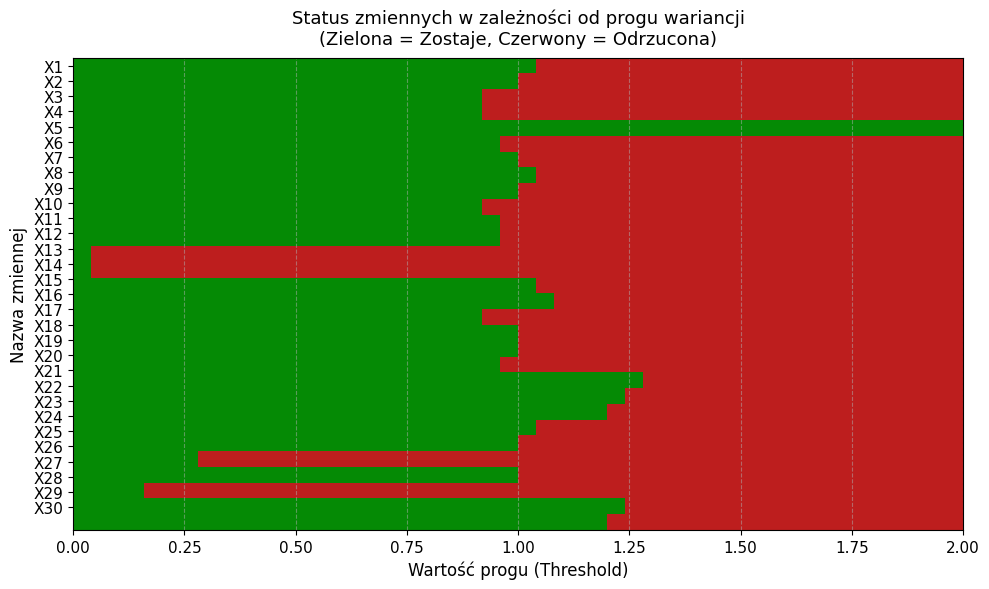

In [6]:
from matplotlib.colors import ListedColormap

cechy_wariancje = df_train.var().sort_values()
progi = np.linspace(0.0, 2.0, 50)

wyniki = []
for p in progi:
    selector = VarianceThreshold(threshold=p)
    selector.fit(df_train)
    wyniki.append(selector.get_support())


df_wyniki = pd.DataFrame(wyniki, index=progi, columns=df_train.columns).T

plt.figure(figsize=(10, 6))

custom_cmap = ListedColormap(['#bd1e1e', '#058a05'])
plt.imshow(df_wyniki.astype(int), cmap=custom_cmap, aspect='auto', 
           extent=[progi.min(), progi.max(), len(df.columns)-0.5, -0.5])


plt.yticks(range(len(df_train.columns)), df_wyniki.index, fontsize=11)
plt.xticks(fontsize=11)


plt.xlabel('Wartość progu (Threshold)', fontsize=12)
plt.ylabel('Nazwa zmiennej', fontsize=12)
plt.title('Status zmiennych w zależności od progu wariancji\n(Zielona = Zostaje, Czerwony = Odrzucona)', fontsize=13, pad=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Korelacja Pearsona

In [18]:
korelacje = df.corr(method='pearson')['Y'].drop('Y')
korelacje_sorted = abs(korelacje)
korelacje_sorted = korelacje_sorted.sort_values(ascending=False)
korelacje_sorted

X1     0.279402
X8     0.271779
X2     0.253759
X27    0.244122
X12    0.229187
X9     0.225549
X3     0.154940
X5     0.154840
X26    0.148011
X23    0.082295
X6     0.070368
X11    0.050963
X15    0.042700
X21    0.042192
X16    0.036647
X13    0.035328
X7     0.034738
X22    0.024899
X30    0.024693
X19    0.023130
X17    0.017228
X4     0.015356
X29    0.008026
X28    0.007792
X20    0.007708
X14    0.006573
X18    0.005778
X10    0.004038
X25    0.003381
X24    0.000857
Name: Y, dtype: float64

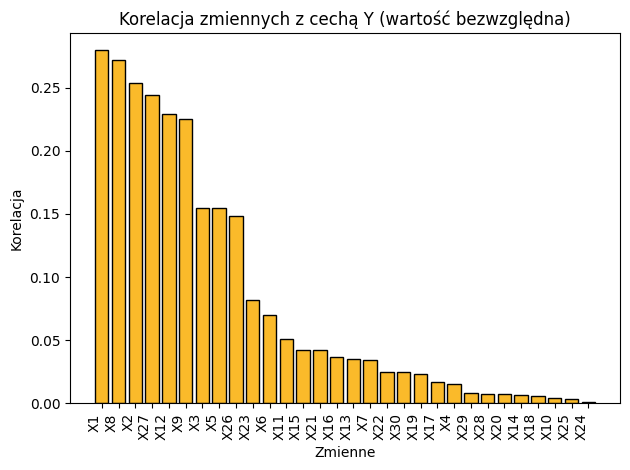

In [27]:
plt.bar(korelacje_sorted.index,korelacje_sorted.values, color='#FABA2A', edgecolor='black')
plt.title('Korelacja zmiennych z cechą Y (wartość bezwzględna)')
plt.xlabel('Zmienne')
plt.ylabel('Korelacja')

plt.xticks(rotation=90, ha='right')
plt.tight_layout() 

plt.show()

In [28]:
korelacja_10 = korelacje_sorted.head(10)
korelacja_10

X1     0.279402
X8     0.271779
X2     0.253759
X27    0.244122
X12    0.229187
X9     0.225549
X3     0.154940
X5     0.154840
X26    0.148011
X23    0.082295
Name: Y, dtype: float64

In [30]:
wyniki_selekcji['Korelacja Pearsona']=korelacja_10.index

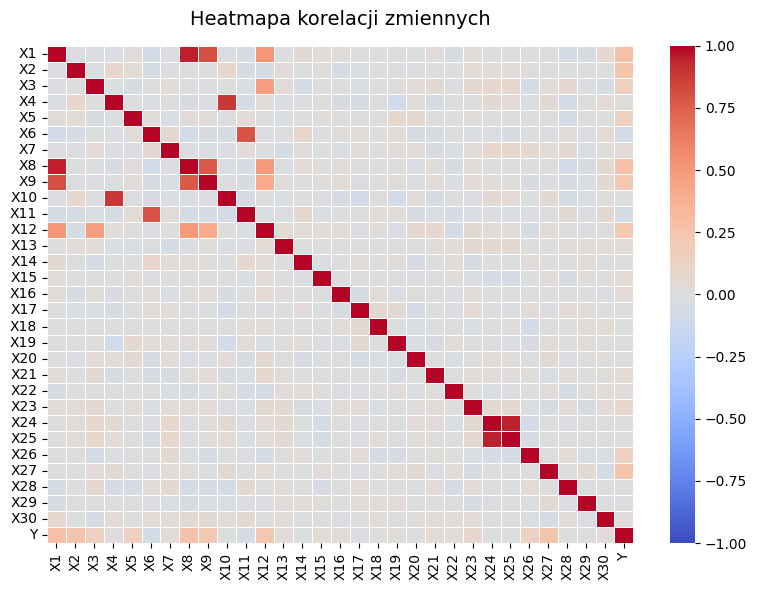

In [32]:
import seaborn as sns

macierz_korelacji = df.corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    macierz_korelacji, 
    cmap='coolwarm',  
    fmt=".2f",        
    vmin=-1, vmax=1,  
    linewidths=0.5,   
    cbar=True         
)

plt.title('Heatmapa korelacji zmiennych', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

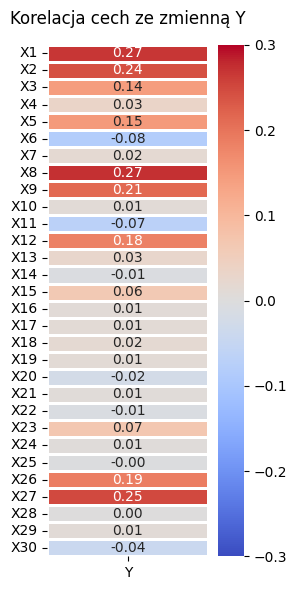

In [21]:
korelacja_Y = df.corr(method='pearson')[['Y']].drop('Y')

plt.figure(figsize=(3, 6))

sns.heatmap(
    korelacja_Y, 
    annot=True,       
    cmap='coolwarm',  
    fmt=".2f",        
    vmin=-0.3, vmax=0.3,  
    linewidths=1,     
    cbar=True        
)

plt.title('Korelacja cech ze zmienną Y', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

## Chi kwadrat

In [33]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2

# Zakładamy, że X ma wartości ujemne
scaler = MinMaxScaler()
X_nieujemne = pd.DataFrame(scaler.fit_transform(df_train))
X_nieujemne.columns = range(1, len(X_nieujemne.columns) + 1)
X_nieujemne

,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
0,0.422438,0.405876,0.290100,0.656817,0.0,0.559566,0.802072,0.427367,0.364991,0.517300,...,1.000000,0.000000,1.000000,0.810868,0.797752,1.0,0.75,0.0,1.000000,0.333333
1,0.348024,0.520708,0.154267,0.763132,0.6,0.386298,0.728554,0.405244,0.464722,0.642932,...,1.000000,1.000000,1.000000,0.624313,0.608387,0.0,0.50,1.0,0.000000,0.666667
2,0.483103,0.400043,0.151202,0.610414,1.0,0.384938,0.460415,0.458416,0.412412,0.600058,...,1.000000,0.000000,0.333333,0.724205,0.643496,0.0,0.50,1.0,1.000000,0.333333
3,0.372956,0.591751,0.065633,0.673560,0.4,0.261702,0.545456,0.412089,0.486502,0.599985,...,1.000000,1.000000,1.000000,0.435315,0.383131,0.0,0.50,1.0,0.333333,0.333333
4,0.487680,0.451481,0.324401,0.344355,0.2,0.637152,0.424158,0.511069,0.277219,0.380939,...,0.333333,1.000000,0.333333,0.769122,0.829445,0.0,0.75,1.0,0.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.226548,0.426927,0.008263,0.715159,0.0,0.317784,0.761893,0.238890,0.411682,0.626693,...,1.000000,1.000000,0.333333,0.281380,0.254506,1.0,0.25,1.0,0.000000,0.000000
996,0.645772,0.409683,0.073214,0.776212,1.0,0.267289,0.704956,0.642766,0.424960,0.749244,...,1.000000,1.000000,1.000000,0.527610,0.580301,0.0,1.00,0.0,1.000000,0.333333
997,0.308980,0.399722,0.274594,0.680142,0.6,0.088419,0.563127,0.324138,0.504803,0.657247,...,0.333333,0.000000,0.000000,0.726189,0.709937,1.0,0.25,1.0,1.000000,0.333333
998,0.477595,0.420060,0.169622,0.365383,0.2,0.649431,0.932128,0.447178,0.521102,0.428712,...,0.666667,0.666667,0.666667,0.410661,0.447012,0.0,0.75,1.0,0.000000,0.666667


In [45]:
chi2_values = chi2(X_nieujemne,Y)[0]
chi2_values = pd.Series(chi2_values, index=df_train.columns).sort_values(ascending=False)
chi2_values

X26    11.085020
X27     7.429416
X5      5.218834
X2      3.843589
X3      3.799746
X1      3.359774
X8      2.851893
X12     2.831545
X9      2.144428
X23     1.772854
X21     0.498054
X6      0.271776
X22     0.169918
X30     0.159763
X11     0.116381
X15     0.102911
X16     0.073733
X13     0.065045
X7      0.049166
X19     0.029180
X29     0.018280
X17     0.014491
X4      0.012025
X28     0.010989
X20     0.003045
X18     0.001787
X14     0.001559
X10     0.000627
X25     0.000610
X24     0.000038
dtype: float64

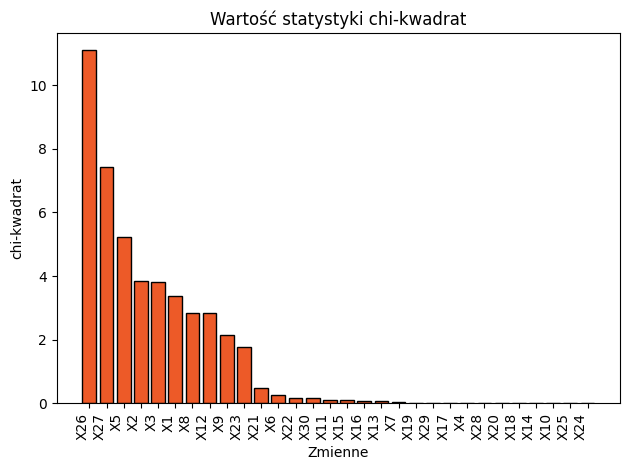

In [52]:
plt.bar(chi2_values.index,chi2_values.values, color='#ED5A28', edgecolor='black')
plt.title('Wartość statystyki chi-kwadrat')
plt.xlabel('Zmienne')
plt.ylabel('chi-kwadrat')

plt.xticks(rotation=90, ha='right')
plt.tight_layout() 

plt.show()

In [48]:
wyniki_selekcji['Chi kwadrat']=chi2_values.head(10).index

## Informacja wzajemna

In [53]:
from sklearn.feature_selection import mutual_info_classif

wyniki_mi = mutual_info_classif(df_train, df['Y'], random_state=111)
info_mutual = pd.Series(wyniki_mi, index=df_train.columns).sort_values(ascending=False)
info_mutual

X8     0.055386
X1     0.050689
X4     0.036464
X5     0.028054
X23    0.027558
X6     0.026011
X20    0.024353
X17    0.022759
X29    0.021118
X2     0.020582
X27    0.019553
X12    0.017939
X18    0.017294
X3     0.015613
X30    0.013221
X10    0.011228
X7     0.010039
X15    0.009593
X28    0.008043
X9     0.005557
X21    0.003565
X22    0.002804
X14    0.000000
X13    0.000000
X19    0.000000
X11    0.000000
X24    0.000000
X25    0.000000
X26    0.000000
X16    0.000000
dtype: float64

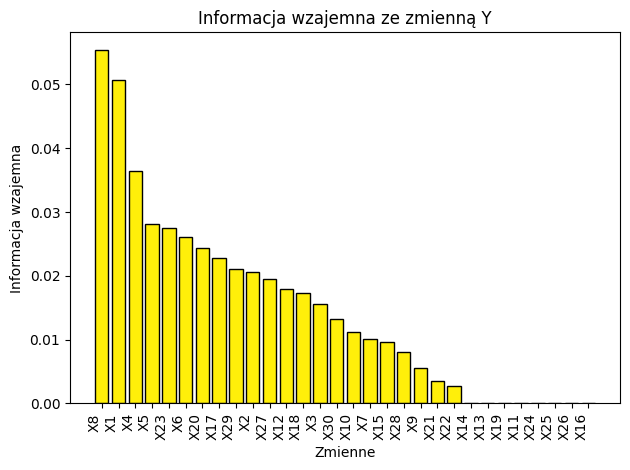

In [57]:
plt.bar(info_mutual.index,info_mutual.values, color='#FFEF0A', edgecolor='black')
plt.title('Informacja wzajemna ze zmienną Y')
plt.xlabel('Zmienne')
plt.ylabel('Informacja wzajemna')

plt.xticks(rotation=90, ha='right')
plt.tight_layout() 

plt.show()

In [58]:
wyniki_selekcji['Informacja Wzajemna']=info_mutual.head(10).index

## Anova

In [61]:
from sklearn.feature_selection import f_classif

wyniki_anova, _ = f_classif(df_train, df['Y'])
anova_scores = pd.Series(wyniki_anova, index=df_train.columns).sort_values(ascending=False)
anova_scores

X1     84.506209
X8     79.595532
X2     68.687979
X27    63.245375
X12    55.327942
X9     53.491715
X3     24.547697
X5     24.515091
X26    22.353032
X23     6.804975
X6      4.966401
X11     2.598796
X15     1.822928
X21     1.779809
X16     1.342127
X13     1.247109
X7      1.205745
X22     0.619124
X30     0.608908
X19     0.534190
X17     0.296311
X4      0.235395
X29     0.064290
X28     0.060595
X20     0.059296
X14     0.043119
X18     0.033314
X10     0.016274
X25     0.011408
X24     0.000734
dtype: float64

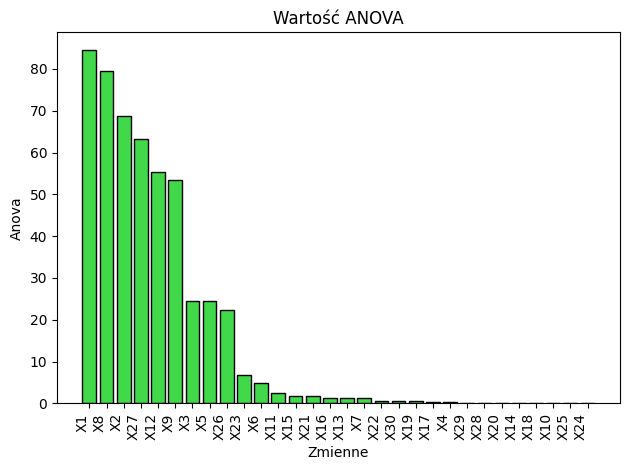

In [63]:
plt.bar(anova_scores.index,anova_scores.values, color='#41D94A', edgecolor='black')
plt.title('Wartość ANOVA')
plt.xlabel('Zmienne')
plt.ylabel('Anova')

plt.xticks(rotation=90, ha='right')
plt.tight_layout() 

plt.show()

In [64]:
wyniki_selekcji['ANOVA']=anova_scores.head(10).index

# Metody wbudowane

## LASSO

In [ ]:


model = LogisticRegression(penalty='l1',solver='liblinear',C=0.1,random_state=111)
model.fit(df_train,df['Y'])

model.coef_[0]

array([ 0.24494208,  0.55861502,  0.27975145,  0.        ,  0.20027651,
       -0.07153005,  0.        ,  0.39162579,  0.        ,  0.        ,
       -0.00574093,  0.        ,  0.        ,  0.        ,  0.06172169,
        0.        ,  0.02351912,  0.        ,  0.        , -0.03035393,
        0.        ,  0.        ,  0.09116584,  0.        ,  0.        ,
        0.5208785 ,  0.46024902,  0.        ,  0.        , -0.10828093])

In [29]:
wagi_cech = pd.Series(model.coef_[0], index=df_train.columns)
wagi_posortowane = abs(wagi_cech).sort_values(ascending=False)
wagi_posortowane

X2     0.558615
X26    0.520879
X27    0.460249
X8     0.391626
X3     0.279751
X1     0.244942
X5     0.200277
X30    0.108281
X23    0.091166
X6     0.071530
X15    0.061722
X20    0.030354
X17    0.023519
X11    0.005741
X22    0.000000
X29    0.000000
X28    0.000000
X4     0.000000
X25    0.000000
X24    0.000000
X9     0.000000
X21    0.000000
X10    0.000000
X19    0.000000
X18    0.000000
X7     0.000000
X14    0.000000
X13    0.000000
X12    0.000000
X16    0.000000
dtype: float64

In [30]:
C_val = np.logspace(-2,1,100)
coefs = []

for c in C_val:
    model = LogisticRegression(penalty='l1',solver='liblinear',C=c,random_state=111)
    model.fit(df_train,df['Y']) 
    coefs.append(model.coef_[0])

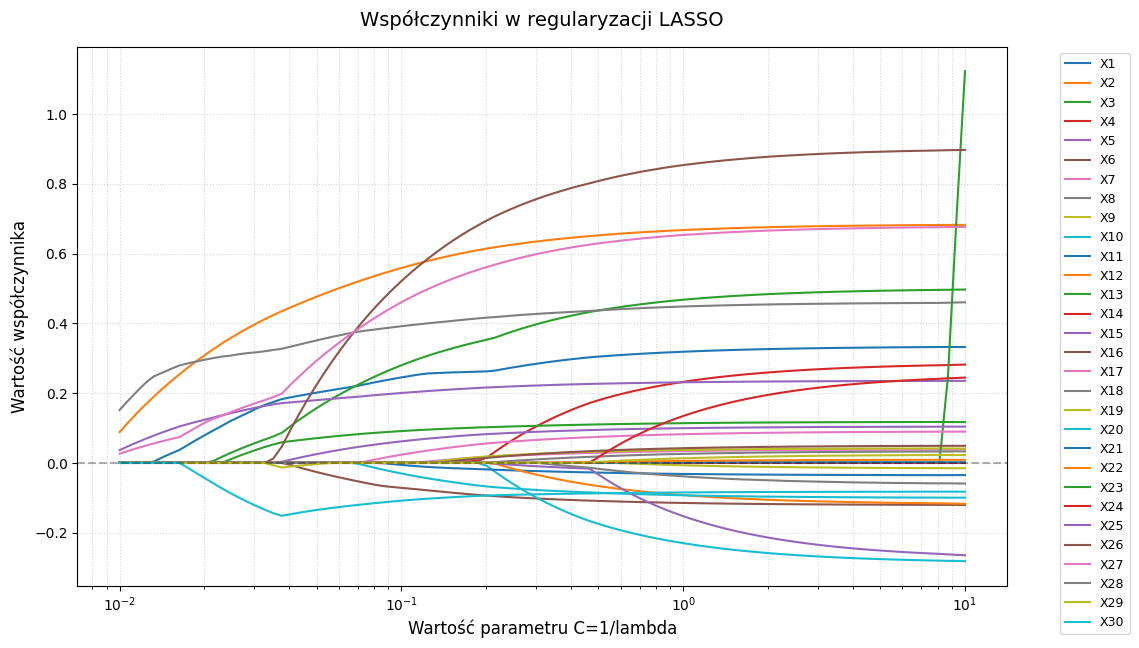

In [ ]:
coefs_array = np.array(coefs)

plt.figure(figsize=(12, 7))
plt.plot(C_val, coefs_array)
plt.xscale('log')

plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.legend(df_train.columns, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Opisy osi i tytuł
plt.xlabel('Wartość parametru C=1/lambda', fontsize=12)
plt.ylabel('Wartość współczynnika', fontsize=12)
plt.title('Współczynniki w regularyzacji LASSO', fontsize=14, pad=15)
plt.grid(True, which="both", linestyle=":", alpha=0.5)

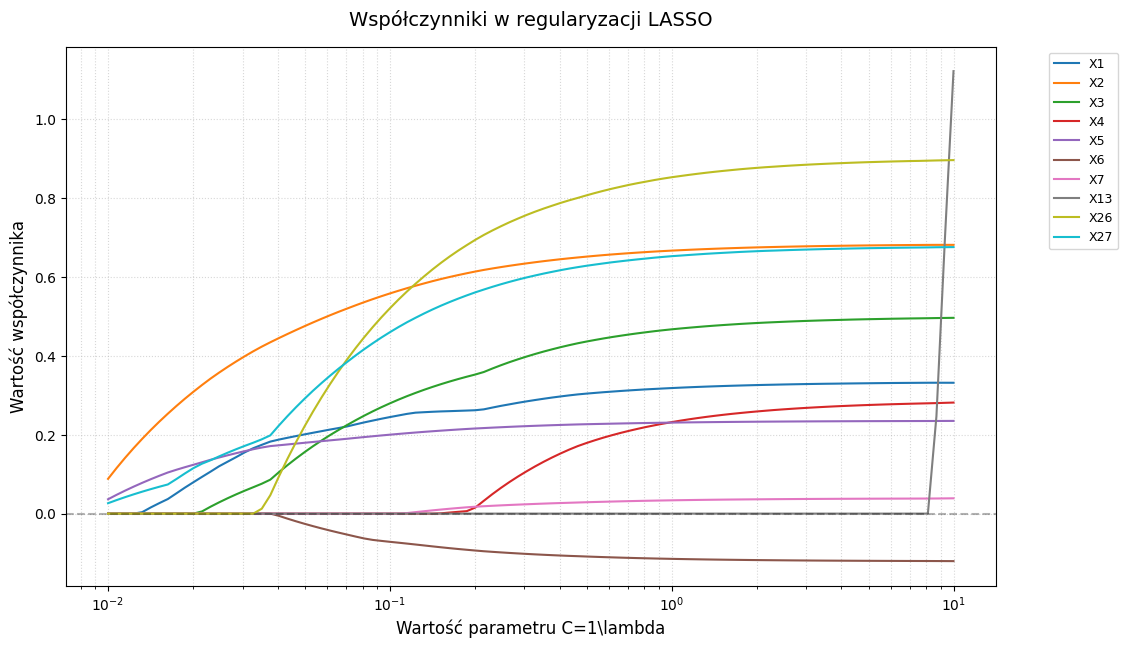

In [32]:
C_val = np.logspace(-2,1,100)
coefs_wybrane = []
wybrane = ['X1', 'X2', 'X3',  'X4', 'X5', 'X6', 'X7', 'X13', 'X26', 'X27']

wybrane_index = [list(df_train.columns).index(f) for f in wybrane]

for c in C_val:
    model = LogisticRegression(penalty='l1',solver='liblinear',C=c,random_state=111)
    model.fit(df_train,df['Y']) 
    coefs_wybrane.append(model.coef_[0][wybrane_index])

coefs_array = np.array(coefs_wybrane)


plt.figure(figsize=(12, 7))


plt.plot(C_val, coefs_array)


plt.xscale('log')


plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.legend(wybrane, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.xlabel('Wartość parametru C=1\lambda', fontsize=12)
plt.ylabel('Wartość współczynnika', fontsize=12)
plt.title('Współczynniki w regularyzacji LASSO', fontsize=14, pad=15)
plt.grid(True, which="both", linestyle=":", alpha=0.5)

In [67]:
model10 = LogisticRegression(penalty='l1',solver='liblinear',C=0.04,random_state=111)
model10.fit(df_train,df['Y'])
wagi_cech10 = pd.Series(model10.coef_[0], index=df_train.columns)
wagi_10 = abs(wagi_cech10).sort_values(ascending=False)
wagi_10 = wagi_10[wagi_10!=0]
wagi_10

X1     0.481277
X2     0.476069
X27    0.221561
X5     0.183176
X3     0.107272
X23    0.080613
X12    0.056168
X29    0.044669
X22    0.028978
X26    0.023692
X21    0.021066
X30    0.018307
X8     0.018052
dtype: float64

In [68]:
wyniki_selekcji['Lasso']=wagi_10.head(10).index

## Random forest

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=111)
rf.fit(df_train,df['Y'])

feature_importance = pd.Series(rf.feature_importances_, index=df_train.columns).sort_values(ascending=False)
feature_importance.head(10)

X2     0.076315
X1     0.064139
X4     0.061330
X8     0.055400
X3     0.046134
X10    0.045651
X12    0.045041
X9     0.042660
X6     0.042105
X7     0.040357
dtype: float64

In [71]:
wyniki_selekcji['Lasso']=feature_importance.head(10).index

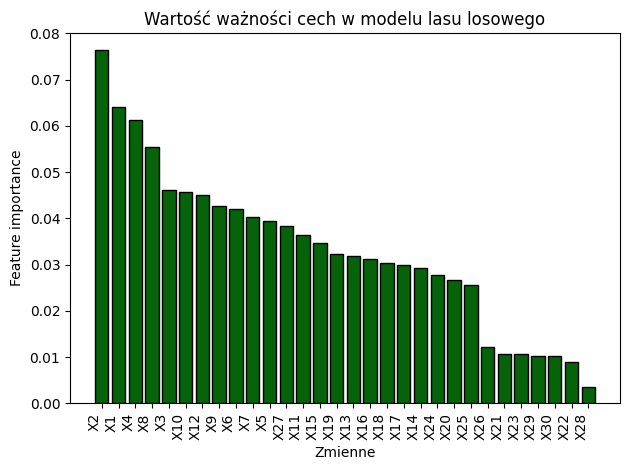

In [82]:
plt.bar(feature_importance.index,feature_importance.values, color='#06630A', edgecolor='black')
plt.title('Wartość ważności cech w modelu lasu losowego')
plt.xlabel('Zmienne')
plt.ylabel('Feature importance')

plt.xticks(rotation=90, ha='right')
plt.tight_layout() 

plt.show()

# Metody obudowane

## Forward Selection

In [83]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=111)

forward = SequentialFeatureSelector(
    model, 
    n_features_to_select=10, 
    direction='forward', 
    cv=5, 
    n_jobs=-1
)

forward.fit(df_train,df['Y'])

,estimator,LogisticRegre...r='liblinear')
,n_features_to_select,10
,tol,None
,direction,'forward'
,scoring,None
,cv,5
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [84]:
wybrane_forward = df_train.columns[forward.get_support()]
wybrane_forward

Index(['X1', 'X2', 'X3', 'X6', 'X11', 'X13', 'X14', 'X27', 'X28', 'X29'], dtype='str')

In [87]:
wyniki_selekcji['Selekcja postępująca']=wybrane_forward

In [85]:
backward = SequentialFeatureSelector(
    model, 
    n_features_to_select=10, 
    direction='backward', 
    cv=5, 
    n_jobs=-1
)

backward.fit(df_train,df['Y'])

,estimator,LogisticRegre...r='liblinear')
,n_features_to_select,10
,tol,None
,direction,'backward'
,scoring,None
,cv,5
,n_jobs,-1
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [86]:
wybrane_backward= df_train.columns[backward.get_support()]
wybrane_backward

Index(['X1', 'X2', 'X3', 'X6', 'X22', 'X23', 'X24', 'X26', 'X27', 'X30'], dtype='str')

In [88]:
wyniki_selekcji['Eliminacja wsteczna']=wybrane_backward

## RFE z random forest

In [89]:
from sklearn.feature_selection import RFECV

rf_model = RandomForestClassifier(random_state=111,n_jobs=-1)


rfecv_selection = RFECV(
    estimator=rf_model, 
    step=1, 
    cv=5, 
    scoring='accuracy', 
    min_features_to_select=10, 
    n_jobs=-1
)

rfecv_selection.fit(df_train,df['Y'])

,estimator,RandomForestC...dom_state=111)
,step,1
,min_features_to_select,10
,cv,5
,scoring,'accuracy'
,verbose,0
,n_jobs,-1
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None


In [90]:
rfecv_cechy = df_train.columns[rfecv_selection.support_]
rfecv_cechy

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X24',
       'X27'],
      dtype='str')

In [91]:
from sklearn.feature_selection import RFE

rfe_selection = RFE(
    estimator=rf_model, 
    step=1,  
    n_features_to_select=10
)

rfe_selection.fit(df_train,df['Y'])

,estimator,RandomForestC...dom_state=111)
,n_features_to_select,10
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [92]:
rfe_cechy = df_train.columns[rfe_selection.support_]
rfe_cechy

Index(['X1', 'X2', 'X3', 'X4', 'X6', 'X7', 'X8', 'X10', 'X11', 'X12'], dtype='str')

In [93]:
wyniki_selekcji['RFE']=rfe_cechy

In [47]:
from sklearn.ensemble import RandomForestClassifier
# Import z nowej, działającej biblioteki
from sklearn_genetic import GAFeatureSelectionCV

# 1. Model oceniający
estimator = RandomForestClassifier(random_state=42, n_jobs=-1)

# 2. Selektor genetyczny
selector_ga = GAFeatureSelectionCV(
    estimator,
    cv=5,
    scoring="accuracy",
    max_features=10,                # Miękki limit: szukamy max 10 cech
    crossover_probability=0.5,
    mutation_probability=0.2,
    n_jobs=-1,
    verbose=True
)

# 3. Uruchomienie ewolucji
selector_ga.fit(df_train, df['Y'])

# 4. Wyciągnięcie cech
wybrane_ga = df_train.columns[selector_ga.support_]
print("\nCechy wybrane przez Algorytm Genetyczny:")
print(wybrane_ga.tolist())

ImportError: Traceback (most recent call last):
  File "c:\Users\wolfd\anaconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: Procedura inicjowania biblioteki dołączanej dynamicznie (DLL) nie powiodła się.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.